In [1]:
# 1. Import our tools
import tensorflow as tf                    # The main Deep Learning library
from tensorflow import keras               # The easy interface
import numpy as np                         # For handling numbers
import matplotlib.pyplot as plt            # For drawing graphs and images

print("All tools imported successfully!")

All tools imported successfully!


In [2]:
# 2. Load the MNIST dataset (it's built into Keras!)
mnist = keras.datasets.mnist

# 3. Split into training and testing sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 4. Print the shapes to understand the data
print("Training data shape (images):", x_train.shape)  # (60000, 28, 28)
print("Training data shape (labels):", y_train.shape)  # (60000,)
print("Test data shape (images):", x_test.shape)       # (10000, 28, 28)
print("Test data shape (labels):", y_test.shape)       # (10000,)

print("\nData loaded successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape (images): (60000, 28, 28)
Training data shape (labels): (60000,)
Test data shape (images): (10000, 28, 28)
Test data shape (labels): (10000,)

Data loaded successfully!


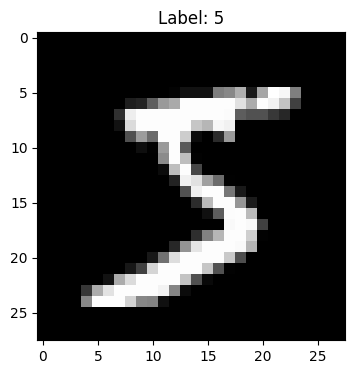

In [4]:
# 5. Look at one image
plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

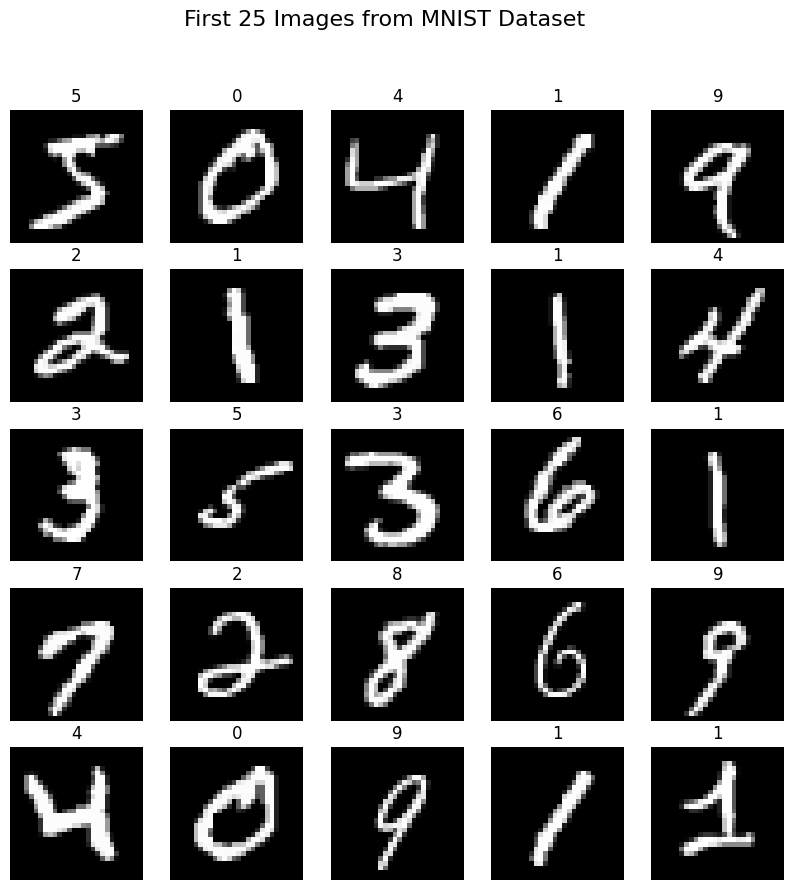

In [5]:
# 6. Show multiple images in a grid
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')
plt.suptitle("First 25 Images from MNIST Dataset", fontsize=16)
plt.show()

In [6]:
# 7. Flatten the images (28x28 → 784)
x_train_flattened = x_train.reshape(x_train.shape[0], 28*28)
x_test_flattened = x_test.reshape(x_test.shape[0], 28*28)

print("Training data shape (flattened):", x_train_flattened.shape)  # (60000, 784)
print("Test data shape (flattened):", x_test_flattened.shape)       # (10000, 784)

# 8. Scale the pixel values (0-255 → 0-1)
x_train_scaled = x_train_flattened / 255.0
x_test_scaled = x_test_flattened / 255.0

print("\nPixel values are now between 0 and 1:")
print("Minimum value:", x_train_scaled.min())
print("Maximum value:", x_train_scaled.max())

Training data shape (flattened): (60000, 784)
Test data shape (flattened): (10000, 784)

Pixel values are now between 0 and 1:
Minimum value: 0.0
Maximum value: 1.0


In [7]:
# 9. One-hot encode the labels
y_train_one_hot = keras.utils.to_categorical(y_train, 10)
y_test_one_hot = keras.utils.to_categorical(y_test, 10)

print("Original label (first 5):", y_train[:5])
print("One-hot encoded label (first 5):")
print(y_train_one_hot[:5])

Original label (first 5): [5 0 4 1 9]
One-hot encoded label (first 5):
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [9]:
# 10. Build the Neural Network
model = keras.Sequential([
    # Input layer: 784 neurons (flattened images)
    # Hidden layer 1: 128 neurons with ReLU activation
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),

    # Hidden layer 2: 64 neurons with ReLU activation
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu')

    # Output layer: 10 neurons with Softmax activation
    keras.layers.Dense(10, activation='softmax')
])

# 11. Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 12. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
# 13. Train the model
history = model.fit(
    x_train_scaled,          # Training images
    y_train_one_hot,         # Training labels (one-hot encoded)
    epochs=5,                # Number of times to see the data
    batch_size=32,           # Number of images to process at once
    validation_split=0.2     # Use 20% of training data for validation
)

print("\nTraining completed!")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9242 - loss: 0.2635 - val_accuracy: 0.9523 - val_loss: 0.1539
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9659 - loss: 0.1126 - val_accuracy: 0.9681 - val_loss: 0.1025
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9756 - loss: 0.0778 - val_accuracy: 0.9699 - val_loss: 0.1004
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9809 - loss: 0.0585 - val_accuracy: 0.9716 - val_loss: 0.0988
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0463 - val_accuracy: 0.9703 - val_loss: 0.1038

Training completed!


In [13]:
# 14. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test_one_hot)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0867

Test Loss: 0.0867
Test Accuracy: 97.33%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


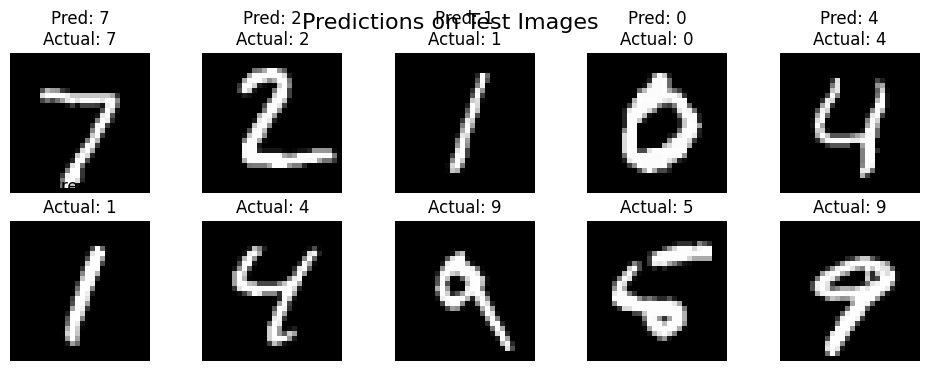

In [14]:
# 15. Make predictions on the first 10 test images
predictions = model.predict(x_test_scaled[:10])
predicted_labels = np.argmax(predictions, axis=1)

# 16. Show the images and predictions
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")
    plt.axis('off')
plt.suptitle("Predictions on Test Images", fontsize=16)
plt.show()

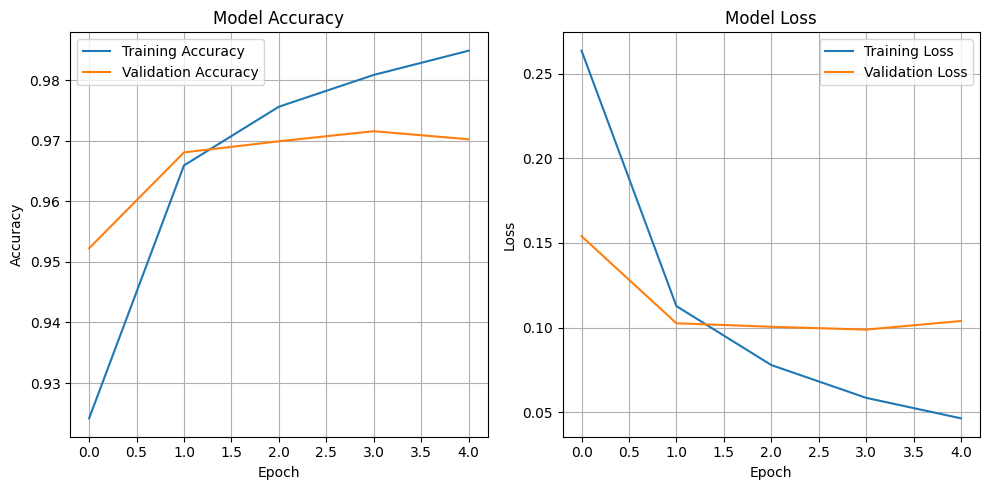

In [16]:
# 17. Plot training history
plt.figure(figsize=(10, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()